In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/YOLO without P5 head"

/content/drive/MyDrive/YOLO without P5 head


In [ ]:
!pip install ultralytics -q
!pip install torch torchvision -q

import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.5 MB/s eta 0:00:00
GPU available: True
Device: Tesla T4


In [ ]:
import shutil, os

DRIVE_DATASET = '/content/drive/MyDrive/YOLO without P5 head/Dataset_Curat_YOLO'
DRIVE_YAMLS   = '/content/drive/MyDrive/YOLO without P5 head'

COLAB_DATASET = '/content/dataset'

if os.path.exists(COLAB_DATASET):
    shutil.rmtree(COLAB_DATASET)
shutil.copytree(DRIVE_DATASET, COLAB_DATASET)

for f in ['data.yaml', 'imcmd_yolov8m_full.yaml', 'imcmd_modules.py']:
    src = os.path.join(DRIVE_YAMLS, f)
    if os.path.exists(src):
        shutil.copy(src, f'/content/{f}')
    else:
        print(f"[WARN] Not found: {src}")

for split in ['train', 'val', 'test']:
    imgs = len(os.listdir(f'{COLAB_DATASET}/{split}/images'))
    lbls = len(os.listdir(f'{COLAB_DATASET}/{split}/labels'))
    print(f"  {split:>5}: {imgs} images, {lbls} labels")

  train: 1672 images, 1672 labels
    val: 358 images, 358 labels
   test: 358 images, 358 labels


In [ ]:
yaml_content = """path: /content/dataset
train: train/images
val:   val/images
test:  test/images

nc: 4
names: ['comedo 0', 'nodul 3', 'papule 1', 'pustule 2']
"""

with open('/content/data.yaml', 'w') as f:
    f.write(yaml_content)

import os
for split in ['train', 'val', 'test']:
    path = f'/content/dataset/{split}/images'
    if os.path.exists(path):
        print(f"  {split}: {len(os.listdir(path))} images")
    else:
        print(f"  [WARN] Missing: {path}")

  train: 1672 images
  val: 358 images
  test: 358 images


# **ANTRENAMENT MULTICLASS YOLOV8M 640PX 150 EPOCI**

In [ ]:
results_multi = model_multi.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_baseline',

    patience=20,

    save=True,
    plots=True
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_multiclass_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

# **Antrenament YOLO multiclass baseline pe rezolutia de 416px**

In [ ]:
from ultralytics import YOLO
model_multi = YOLO('yolov8m.pt')

results_multi = model_multi.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=416,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_baseline_416',

    patience=20,

    save=True,
    plots=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int

# **ABLATIE CLS_PW: ANTRENAMENT MULTICLASS YOLOV8M 640PX 150 EPOCI**

In [ ]:
from ultralytics import YOLO
model_multi = YOLO('yolov8m.pt')

results_clspw = model_multi.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_clspw_0.5',
    patience=20,
    save=True,
    plots=True,
    cls_pw=0.5
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int

# **ABLATIE CLS_PW: ANTRENAMENT MULTICLASS YOLOV8M 416PX 150 EPOCI**

In [ ]:
from ultralytics import YOLO
model_multi = YOLO('yolov8m.pt')

results_clspw = model_multi.train(
    data='/content/data.yaml', # Ramane setul original
    epochs=150,
    imgsz=416,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_clspw_0.5_416',
    patience=20,
    save=True,
    plots=True,
    cls_pw=0.5
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_multiclass_clspw_0.5_416-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

# **ABLATIE MULTISCALE TRAINING: ANTRENAMENT MULTICLASS YOLOV8M 640PX 150 EPOCI**

In [ ]:
from ultralytics import YOLO
model_multi = YOLO('yolov8m.pt')

results_ms = model_multi.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_multiscale_0.5',
    patience=20,
    save=True,
    plots=True,
    multi_scale=0.5
)

New https://pypi.org/project/ultralytics/8.4.40 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.5, name=yolov8m_multic

# **ABLATIE MULTISCALE TRAINING: ANTRENAMENT MULTICLASS YOLOV8M 416px 150 EPOCI**

In [ ]:
from ultralytics import YOLO
model_multi = YOLO('yolov8m.pt')

results_ms = model_multi.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=416,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_multiscale_0.5_416',
    patience=20,
    save=True,
    plots=True,
    multi_scale=0.5
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.5, name=yolov8m_multiclass_multiscale_0.5_416, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

# **ABLATIE COPY PASTE CU MOSAIC + MIXUP + COPY PASTE din parametrii YOLO**

In [ ]:
from ultralytics import YOLO
model_multi = YOLO('yolov8m.pt')

results_clspw = model_multi.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_augumentari_mosaic_mixup_copypaste',
    patience=20,
    save=True,
    plots=True,

    mosaic = 1.0,
    mixup = 0.1,
    copy_paste = 0.1
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int

# **ABLATIE COPY PASTE CU MOSAIC + MIXUP + COPY PASTE din parametrii YOLO cu 416px**

In [ ]:
from ultralytics import YOLO
model_multi = YOLO('yolov8m.pt')

results_clspw = model_multi.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=416,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_augumentari_mosaic_mixup_copypaste_416',
    patience=20,
    save=True,
    plots=True,

    mosaic = 1.0,
    mixup = 0.1,
    copy_paste = 0.1
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_multiclass_augumentari_mosaic_mixup_copypaste_416, nbs=64, nms=False, opset=None, optimize=False, optimizer

# **ABLATIE COPY PASTE CU MOSAIC + MIXUP + COPY PASTE din parametrii YOLO + CLS_pw = 0.5 care a dat improve mai devreme!**

In [ ]:
from ultralytics import YOLO
model_multi = YOLO('yolov8m.pt')

results_clspw = model_multi.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_augumentari_mosaic_mixup_copypaste_cls_pw',
    patience=20,
    save=True,
    plots=True,

    mosaic = 1.0,
    mixup = 0.1,
    copy_paste = 0.1,
    cls_pw = 0.5
)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_multiclass_augumentari_mosaic_mixup_copypaste_cls_pw, nbs=64, nms=False, opset=None, optimize=False, optimi

# **RESUME:**

In [ ]:
from ultralytics import YOLO
cale_checkpoint = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_multiclass_augumentari_mosaic_mixup_copypaste_cls_pw/weights/last.pt'
model_multi = YOLO(cale_checkpoint)

results_clspw = model_multi.train(resume=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int

# **ABLATIE COPY PASTE CU MOSAIC + MIXUP + COPY PASTE din parametrii YOLO + CLS_pw = 0.5 care a dat improve mai devreme pe 416px!**

In [ ]:
from ultralytics import YOLO
model_multi = YOLO('yolov8m.pt')

results_clspw = model_multi.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=416,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_augumentari_mosaic_mixup_copypaste_cls_pw_416',
    patience=20,
    save=True,
    plots=True,

    mosaic = 1.0,
    mixup = 0.1,
    copy_paste = 0.1,
    cls_pw = 0.5
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_multiclass_augumentari_mosaic_mixup_copypaste_cls_pw_416, nbs=64, nms=False, opset=None, optimize=False, op

# **Ablatie copy-paste augumentation - Doar pe setul de train**

In [ ]:
import shutil, os

# ── EDIT THIS ──────────────────────────────────────────────
DRIVE_DATASET = '/content/drive/MyDrive/YOLO without P5 head/Dataset_augumentat'
DRIVE_YAMLS   = '/content/drive/MyDrive/YOLO without P5 head'
# ───────────────────────────────────────────────────────────

COLAB_DATASET = '/content/dataset'

# Copy dataset to fast local SSD (much faster I/O than Drive)
if os.path.exists(COLAB_DATASET):
    shutil.rmtree(COLAB_DATASET)
shutil.copytree(DRIVE_DATASET, COLAB_DATASET)

# Copy yaml configs
for f in ['data.yaml', 'imcmd_yolov8m_full.yaml', 'imcmd_modules.py']:
    src = os.path.join(DRIVE_YAMLS, f)
    if os.path.exists(src):
        shutil.copy(src, f'/content/{f}')
    else:
        print(f"[WARN] Not found: {src}")

# Verify structure
for split in ['train', 'val', 'test']:
    imgs = len(os.listdir(f'{COLAB_DATASET}/{split}/images'))
    lbls = len(os.listdir(f'{COLAB_DATASET}/{split}/labels'))
    print(f"  {split:>5}: {imgs} images, {lbls} labels")

  train: 3344 images, 3344 labels
    val: 358 images, 358 labels
   test: 358 images, 358 labels


In [ ]:
yaml_content = """path: /content/dataset
train: train/images
val:   val/images
test:  test/images

nc: 4
names: ['comedo 0', 'nodul 3', 'papule 1', 'pustule 2']
"""

with open('/content/data.yaml', 'w') as f:
    f.write(yaml_content)

# Verify the splits exist and print counts
import os
for split in ['train', 'val', 'test']:
    path = f'/content/dataset/{split}/images'
    if os.path.exists(path):
        print(f"  {split}: {len(os.listdir(path))} images")
    else:
        print(f"  [WARN] Missing: {path}")

  train: 3344 images
  val: 358 images
  test: 358 images


# **Antrenament copy-paste YOLO Doar pe setul de train pe 640px:**

In [ ]:
from ultralytics import YOLO
model_multi = YOLO('yolov8m.pt')


results_copy_paste = model_multi.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_augmented_manual',
    patience=20,
    save=True,
    plots=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int

# **Antrenament copy-paste YOLO Doar pe setul de train pe rezolutia de 416px:**

In [ ]:
from ultralytics import YOLO
model_multi = YOLO('yolov8m.pt')


results_copy_paste = model_multi.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=416,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_augmented_manual_416',
    patience=20,
    save=True,
    plots=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int

# **Antrenament cls_pw + multiscale pe 640px:**

In [ ]:
from ultralytics import YOLO
model_multi = YOLO('yolov8m.pt')

results_clspw = model_multi.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_clspw_0.5_multiscale_0.5',
    patience=20,
    save=True,
    plots=True,
    cls_pw=0.5,
    multi_scale = 0.5
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.5, name=yolov8m_multiclass_clspw_0.5_multiscale_0.5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

# **Evaluare MULTICLASS pe TEST set - 640px**

In [ ]:
from ultralytics import YOLO

best_multi_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_multiclass_baseline/weights/best.pt'
model_multi_eval = YOLO(best_multi_path)

print("Evaluare multiclass baseline")
metrics_multi = model_multi_eval.val(
    data='/content/data.yaml',
    split='test',
)

Evaluare multiclass baseline
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1058.4±296.4 MB/s, size: 23.1 KB)
val: Scanning /content/dataset/test/labels.cache... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 150.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.8it/s 12.9s
                   all        358       3422      0.353      0.313      0.279      0.104
              comedo 0        213        922      0.418       0.35      0.324      0.116
               nodul 3         99        717      0.311       0.29      0.247      0.098
              papule 1        261       1366      0.333      0.359      0.289      0.109
             pustule 2         98        417      0.351      0.254      0.254     0.0917
Speed: 1.9ms prep

# **Evaluare MULTICLASS pe TEST set - 416px**

In [ ]:
from ultralytics import YOLO

best_multi_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_multiclass_baseline_416/weights/best.pt'
model_multi_eval = YOLO(best_multi_path)

print("Evaluare multiclass baseline")
metrics_multi = model_multi_eval.val(
    data='/content/data.yaml',
    split='test',
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Evaluare multiclass baseline
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 887.2±376.5 MB/s, size: 27.7 KB)
val: Scanning /content/dataset/test/labels... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 1.4Kit/s 0.3s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 2.5it/s 9.2s
                   all        358       3422      0.377      0.365      0.303      0.109
             

# **EVALUARE MULTICLASS CLS_PW = 0.5 PE 640PX**

In [ ]:
from ultralytics import YOLO

best_multi_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_multiclass_clspw_0.5/weights/best.pt'
model_multi_eval = YOLO(best_multi_path)

print("Evaluare multiclass cu parametru cls_pw = 0.5")
metrics_multi = model_multi_eval.val(
    data='/content/data.yaml',
    split='test',
)

Evaluare multiclass cu parametru cls_pw = 0.5
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1058.1±536.9 MB/s, size: 24.4 KB)
val: Scanning /content/dataset/test/labels.cache... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 136.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.7it/s 13.8s
                   all        358       3422       0.39      0.337      0.294      0.113
              comedo 0        213        922      0.508      0.322      0.342      0.123
               nodul 3         99        717      0.269      0.382      0.243      0.106
              papule 1        261       1366      0.373      0.359      0.303      0.116
             pustule 2         98        417      0.412      0.283      0.289      0.108


# **EVALUARE MULTICLASS CLS_PW = 0.5 pe 416px**

In [ ]:
from ultralytics import YOLO

best_multi_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_multiclass_clspw_0.5_416-2/weights/best.pt'
model_multi_eval = YOLO(best_multi_path)

print("Evaluare multiclass cu parametru cls_pw = 0.5 cu 416px")
metrics_multi = model_multi_eval.val(
    data='/content/data.yaml',
    split='test',
)

Evaluare multiclass cu parametru cls_pw = 0.5 cu 416px
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1137.9±205.6 MB/s, size: 26.2 KB)
val: Scanning /content/dataset/test/labels.cache... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 150.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.0it/s 7.7s
                   all        358       3422      0.353      0.343      0.277      0.101
              comedo 0        213        922      0.435      0.309      0.292      0.102
               nodul 3         99        717      0.335      0.318      0.246     0.0935
              papule 1        261       1366      0.331      0.413       0.31      0.113
             pustule 2         98        417      0.311      0.332      0.259    

# **EVALUARE MULTICLASS MULTI_SCALE = 0.5 PE 640PX**

In [ ]:
from ultralytics import YOLO

best_multi_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_multiclass_multiscale_0.5/weights/best.pt'
model_multi_eval = YOLO(best_multi_path)

print("Evaluare multiclass cu parametru multi_scale = 0.5")
metrics_multi = model_multi_eval.val(
    data='/content/data.yaml',
    split='test',
)

Evaluare multiclass cu parametru multi_scale = 0.5
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 670.9±141.2 MB/s, size: 22.4 KB)
val: Scanning /content/dataset/test/labels.cache... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 100.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.7it/s 13.2s
                   all        358       3422      0.366      0.338      0.278      0.105
              comedo 0        213        922      0.394      0.358      0.295      0.104
               nodul 3         99        717      0.294      0.374      0.255      0.108
              papule 1        261       1366      0.346      0.371      0.295      0.112
             pustule 2         98        417      0.431      0.249      0.265     0.0

# **EVALUARE MULTICLASS MULTI_SCALE = 0.5 pe 416px**

In [ ]:
from ultralytics import YOLO

best_multi_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_multiclass_multiscale_0.5_416/weights/best.pt'
model_multi_eval = YOLO(best_multi_path)

print("Evaluare multiclass cu parametru multi_scale = 0.5 cu 416px")
metrics_multi = model_multi_eval.val(
    data='/content/data.yaml',
    split='test',
)

Evaluare multiclass cu parametru multi_scale = 0.5 cu 416px
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 696.2±155.8 MB/s, size: 28.9 KB)
val: Scanning /content/dataset/test/labels.cache... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 93.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 2.2it/s 10.6s
                   all        358       3422      0.339      0.355      0.271     0.0998
              comedo 0        213        922      0.415      0.387      0.316      0.109
               nodul 3         99        717      0.328      0.303       0.23     0.0922
              papule 1        261       1366       0.34      0.335       0.26     0.0946
             pustule 2         98        417      0.273      0.393      0.277

# **EVALUARE MULTICLASS COPY PASTE AUGUMENTATION MANUAL**

In [ ]:
from ultralytics import YOLO

best_multi_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_multiclass_augmented_manual/weights/best.pt'
model_multi_eval = YOLO(best_multi_path)

print("Evaluare YOLO multiclass cu augumentari facute manual prin opencv")
metrics_multi = model_multi_eval.val(
    data='/content/data.yaml',
    split='test',
)

Evaluare YOLO multiclass cu augumentari facute manual prin opencv
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 802.2±372.3 MB/s, size: 33.1 KB)
val: Scanning /content/dataset/test/labels... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 1.8Kit/s 0.2s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.7it/s 13.6s
                   all        358       3422      0.345       0.33      0.249     0.0879
              comedo 0        213        922      0.375      0.405      0.277     0.0966
               nodul 3         99        717      0.339      0.296      0.232     0.0832
              papule 1        261       1366      0.344      0.371      0.276      0.102
             pustul

# **EVALUARE MULTICLASS COPY PASTE AUGUMENTATION MANUAL pe 416px**

In [ ]:
from ultralytics import YOLO

best_multi_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_multiclass_augmented_manual_416/weights/best.pt'
model_multi_eval = YOLO(best_multi_path)

print("Evaluare YOLO multiclass cu augumentari facute manual prin opencv")
metrics_multi = model_multi_eval.val(
    data='/content/data.yaml',
    split='test',
)

Evaluare YOLO multiclass cu augumentari facute manual prin opencv
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 17.9±4.9 MB/s, size: 28.0 KB)
val: Scanning /content/dataset/test/labels... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 685.1it/s 0.5s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.0it/s 7.6s
                   all        358       3422      0.309      0.333      0.235     0.0813
              comedo 0        213        922      0.356      0.403      0.284     0.0942
               nodul 3         99        717      0.333      0.278      0.231      0.083
              papule 1        261       1366      0.347      0.398      0.301      0.102
             pustule 2

# **Evaluare Ablatie YOLO cu mosaic, mixup si copy_paste PE 640PX**

In [ ]:
from ultralytics import YOLO

best_multi_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_multiclass_augumentari_mosaic_mixup_copypaste/weights/best.pt'
model_multi_eval = YOLO(best_multi_path)

print("Evaluare multiclass cu parametrii mosaic = 1.0, mixup = 0.1 si copy_paste = 0.1")
metrics_multi = model_multi_eval.val(
    data='/content/data.yaml',
    split='test',
)

Evaluare multiclass cu parametrii mosaic = 1.0, mixup = 0.1 si copy_paste = 0.1
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 18.4±10.1 MB/s, size: 28.0 KB)
val: Scanning /content/dataset/test/labels... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 703.3it/s 0.5s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.9it/s 12.0s
                   all        358       3422      0.359      0.355      0.281      0.107
              comedo 0        213        922      0.419      0.383      0.318      0.112
               nodul 3         99        717      0.279      0.357      0.228     0.0943
              papule 1        261       1366      0.306      0.419      0.296      0.115
      

# **Evaluare Ablatie YOLO cu mosaic, mixup si copy_paste cu 416px**

In [ ]:
from ultralytics import YOLO

best_multi_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_multiclass_augumentari_mosaic_mixup_copypaste_416/weights/best.pt'
model_multi_eval = YOLO(best_multi_path)

print("Evaluare multiclass cu parametrii mosaic = 1.0, mixup = 0.1 si copy_paste = 0.1 pe 416px")
metrics_multi = model_multi_eval.val(
    data='/content/data.yaml',
    split='test',
)

Evaluare multiclass cu parametrii mosaic = 1.0, mixup = 0.1 si copy_paste = 0.1 pe 416px
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1392.9±440.1 MB/s, size: 29.1 KB)
val: Scanning /content/dataset/test/labels.cache... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 166.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.4it/s 6.8s
                   all        358       3422      0.374      0.351      0.278      0.102
              comedo 0        213        922      0.463      0.369      0.335      0.116
               nodul 3         99        717      0.309      0.296      0.197     0.0791
              papule 1        261       1366       0.32      0.419      0.284      0.105
             pustule 2         98        417   

# **Evaluare Ablatie YOLO cu mosaic, mixup si copy_paste + cls_pw = 0.5 PE 640PX**

In [ ]:
from ultralytics import YOLO

best_multi_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_multiclass_augumentari_mosaic_mixup_copypaste_cls_pw/weights/best.pt'
model_multi_eval = YOLO(best_multi_path)

print("Evaluare multiclass cu parametrii mosaic = 1.0, mixup = 0.1 si copy_paste = 0.1 + cls_pw = 0.5")
metrics_multi = model_multi_eval.val(
    data='/content/data.yaml',
    split='test',
)

Evaluare multiclass cu parametrii mosaic = 1.0, mixup = 0.1 si copy_paste = 0.1 + cls_pw = 0.5
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.8±1.8 ms, read: 808.5±521.7 MB/s, size: 34.1 KB)
val: Scanning /content/dataset/test/labels.cache... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 79.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.9it/s 12.4s
                   all        358       3422      0.359      0.344       0.29       0.11
              comedo 0        213        922      0.428      0.383      0.339      0.117
               nodul 3         99        717      0.294       0.31      0.234     0.0949
              papule 1        261       1366      0.314      0.396      0.287       0.11
             pustule 2         98        4

# **Evaluare Ablatie YOLO cu mosaic, mixup si copy_paste + cls_pw = 0.5 pe 416px**

In [ ]:
from ultralytics import YOLO

best_multi_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_multiclass_augumentari_mosaic_mixup_copypaste_cls_pw_416/weights/best.pt'
model_multi_eval = YOLO(best_multi_path)

print("Evaluare multiclass cu parametrii mosaic = 1.0, mixup = 0.1 si copy_paste = 0.1 + cls_pw = 0.5 pe 416px")
metrics_multi = model_multi_eval.val(
    data='/content/data.yaml',
    split='test',
)

Evaluare multiclass cu parametrii mosaic = 1.0, mixup = 0.1 si copy_paste = 0.1 + cls_pw = 0.5 pe 416px
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1150.8±459.3 MB/s, size: 20.9 KB)
val: Scanning /content/dataset/test/labels.cache... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 115.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.4it/s 6.8s
                   all        358       3422      0.368      0.318      0.271     0.0993
              comedo 0        213        922      0.419      0.326      0.301      0.102
               nodul 3         99        717      0.309      0.315      0.233     0.0928
              papule 1        261       1366      0.361      0.358      0.298      0.108
             pustule 2         9

# **YOLOV8m tunat:**

In [ ]:
from ultralytics import YOLO

model_multi = YOLO('yolov8m.pt')   # pretrained on COCO

results_multi = model_multi.train(
    # ── data ──────────────────────────────────────────────────────────────────
    data='/content/data.yaml',
    imgsz=640,
    batch=16,

    # ── training schedule ─────────────────────────────────────────────────────
    epochs=150,
    patience=25,            # slightly more patience — medical data is noisy
    cos_lr=True,            # cosine LR decay — smoother than step decay
    warmup_epochs=5,        # warm up for 5 epochs before full LR

    # ── optimizer ─────────────────────────────────────────────────────────────
    optimizer='AdamW',      # better than SGD for small/imbalanced datasets
    lr0=5e-4,               # initial LR — lower than default 1e-2 for medical
    lrf=0.01,               # final LR = lr0 * lrf = 5e-6
    weight_decay=5e-4,
    momentum=0.937,

    # ── augmentation — tuned for small dense lesions ──────────────────────────
    mosaic=0.8,             # default 1.0 can destroy micro-lesions context
    mixup=0.1,              # light mixup helps generalisation
    copy_paste=0.3,         # copies small objects — directly helps your 10-20px lesions
    degrees=10.0,           # small rotation
    translate=0.1,
    scale=0.3,              # scale jitter
    fliplr=0.5,
    flipud=0.1,             # faces can be upside down in dataset

    # ── hardware & logging ────────────────────────────────────────────────────
    device=0,
    workers=4,              # Colab has 2 CPUs, keep at 2-4
    save=True,
    plots=True,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_v2',
    exist_ok=False,
)

print(f"\nBest mAP@0.5:     {results_multi.results_dict['metrics/mAP50(B)']:.4f}")
print(f"Best mAP@0.5:0.95: {results_multi.results_dict['metrics/mAP50-95(B)']:.4f}")

# **RT-DETR R50**

In [ ]:
from ultralytics import RTDETR

# rtdetr-l.pt = RT-DETR Large → ResNet-50 backbone (this is what you want)
# rtdetr-x.pt = RT-DETR Extra  → ResNet-101 backbone (heavier, marginal gain)
model_rtdetr = RTDETR('rtdetr-l.pt')

results_rtdetr = model_rtdetr.train(
    # ── data ──────────────────────────────────────────────────────────────────
    data='/content/data.yaml',
    imgsz=640,
    batch=8,                # RT-DETR is heavier than YOLO — halve the batch

    # ── training schedule ─────────────────────────────────────────────────────
    epochs=150,
    patience=25,
    cos_lr=True,
    warmup_epochs=3,        # shorter warmup — transformer encoders stabilise faster

    # ── optimizer — RT-DETR paper uses AdamW, NOT SGD ─────────────────────────
    optimizer='AdamW',
    lr0=1e-4,               # CRITICAL: RT-DETR needs lower LR than YOLO
                            # default 1e-2 will diverge the transformer encoder
    lrf=0.01,               # final LR = 1e-6
    weight_decay=1e-4,

    # ── augmentation ──────────────────────────────────────────────────────────
    # RT-DETR uses its own augmentation pipeline internally
    # mosaic and copy_paste still apply at the dataset level
    mosaic=0.5,             # less aggressive than YOLO — DETR is sensitive to mosaic
    copy_paste=0.3,         # keep this — helps small lesion detection
    mixup=0.0,              # do NOT use mixup with RT-DETR — degrades transformer attention
    degrees=10.0,
    translate=0.1,
    scale=0.3,
    fliplr=0.5,
    flipud=0.1,

    # ── hardware & logging ────────────────────────────────────────────────────
    device=0,
    workers=4,
    save=True,
    plots=True,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='rtdetr_r50_acnee',
    exist_ok=False,
)

print(f"\nBest mAP@0.5:      {results_rtdetr.results_dict['metrics/mAP50(B)']:.4f}")
print(f"Best mAP@0.5:0.95: {results_rtdetr.results_dict['metrics/mAP50-95(B)']:.4f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/150      7.68G      1.958     0.4507     0.6567         65        640: 100% ━━━━━━━━━━━━ 209/209 1.4it/s 2:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.7it/s 13.6s
                   all        358       4495   0.000263     0.0294   6.36e-05   1.06e-05

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/150      6.71G      1.647     0.3554     0.4343         81        640: 0% ──────────── 0/209  0.8s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/150      7.28G       1.78      0.271     0.4872        132        640: 100% ━━━━━━━━━━━━ 209/209 1.5it/s 2:21
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 2.9it/s 7.9s
                   all        358       4495     0.0001     0.0207   9.79e-05   1.53e-05

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/150      6.59G       1.81     0.1917     0.5222         99        640: 0% ──────────── 0/209  0.7s

...

    110/150      7.27G     0.7087     0.6261     0.1212        131        640: 100% ━━━━━━━━━━━━ 209/209 1.4it/s 2:24
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.1it/s 7.5s
                   all        358       4495      0.297      0.297      0.179     0.0602

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
    111/150      7.27G     0.6898      0.626     0.1522         91        640: 0% ──────────── 0/209  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    111/150      7.27G     0.7179     0.6188     0.1223        108        640: 100% ━━━━━━━━━━━━ 209/209 1.5it/s 2:21
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.0it/s 7.7s
                   all        358       4495      0.297      0.292       0.18       0.06

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
    112/150      7.27G     0.9929     0.4987     0.1412        154        640: 0% ──────────── 0/209  0.7s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    112/150      7.27G     0.7086     0.6174     0.1214         48        640: 100% ━━━━━━━━━━━━ 209/209 1.5it/s 2:21
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.0it/s 7.7s
                   all        358       4495      0.307      0.295      0.184      0.063
EarlyStopping: Training stopped early as no improvement observed in last 25 epochs. Best results observed at epoch 87, best model saved as best.pt.
To update EarlyStopping(patience=25) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

112 epochs completed in 4.739 hours.
Optimizer stripped from /content/drive/MyDrive/YOLO without P5 head/runs/rtdetr_r50_acnee/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/YOLO without P5 head/runs/rtdetr_r50_acnee/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/YOLO without P5 head/runs/rtdetr_r50_acnee/weights/best.pt...
Ultralytics 8.4.37 🚀 Pyth

In [ ]:
# **ANTRENAMENT MULTICLASS YOLOV8M 640PX 150 EPOCI cu AUGUMENTARI **

# **Antrenament EfficientDet**

# **Conversie adnotari din format YOLO in COCO:**

In [ ]:
import os
import json
import cv2
from pathlib import Path

DATASET_PATH = "/content/dataset"

CLASSES = ["comedo", "nodul", "papule", "pustule"]

def yolo_to_coco(split_name):
    img_dir = Path(DATASET_PATH) / split_name / "images"
    lbl_dir = Path(DATASET_PATH) / split_name / "labels"

    if not img_dir.exists() or not lbl_dir.exists():
        print(f"Skipping {split_name} - folderele nu există.")
        return

    coco_dict = {
        "images": [],
        "annotations": [],
        "categories": [{"id": i, "name": name} for i, name in enumerate(CLASSES)]
    }

    ann_id = 0
    img_id = 0

    # Parcurgem imaginile
    for img_name in os.listdir(img_dir):
        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        img_path = img_dir / img_name
        lbl_path = lbl_dir / (img_path.stem + ".txt")

        # de vauzt pt fiecare imagine ce latime si inaltime are
        img = cv2.imread(str(img_path))
        if img is None: continue
        h_img, w_img = img.shape[:2]

        coco_dict["images"].append({
            "id": img_id,
            "file_name": img_name,
            "width": w_img,
            "height": h_img
        })

        # de procesat si folderul de labeluri
        if lbl_path.exists():
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) < 5: continue

                    class_id = int(parts[0])
                    cx_norm, cy_norm, w_norm, h_norm = map(float, parts[1:5])

                    # conversie YOLO -> COCO
                    box_w = w_norm * w_img
                    box_h = h_norm * h_img
                    x_min = (cx_norm * w_img) - (box_w / 2)
                    y_min = (cy_norm * h_img) - (box_h / 2)

                    coco_dict["annotations"].append({
                        "id": ann_id,
                        "image_id": img_id,
                        "category_id": class_id,
                        "bbox": [x_min, y_min, box_w, box_h],
                        "area": box_w * box_h,
                        "iscrowd": 0
                    })
                    ann_id += 1

        img_id += 1

    output_file = Path(DATASET_PATH) / f"{split_name}_coco.json"
    with open(output_file, 'w') as f:
        json.dump(coco_dict, f)
    print(f"Generat cu succes: {output_file} (Imagini: {img_id}, Bounding Boxes: {ann_id})")

for split in ["train", "val", "test"]:
    yolo_to_coco(split)

Generat cu succes: /content/dataset/train_coco.json (Imagini: 1672, Bounding Boxes: 17669)
Generat cu succes: /content/dataset/val_coco.json (Imagini: 358, Bounding Boxes: 4495)
Generat cu succes: /content/dataset/test_coco.json (Imagini: 358, Bounding Boxes: 3422)


In [ ]:
!pip install effdet pycocotools albumentations omegaconf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 11.4 MB/s eta 0:00:00


# **Script antrenament:**

In [ ]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

# Importurile specifice pentru arhitectura EfficientDet
from effdet.factory import create_model_from_config
from effdet.config import get_efficientdet_config
from effdet import create_model

# ---------------------------------------------------------------------------
# ── 1. CONFIGURARE ȘI INIȚIALIZARE MODEL EFFICIENTDET ──────────────────────
# ---------------------------------------------------------------------------
MODEL_NAME = 'efficientdet_d1'
NUM_CLASSES = 4
BATCH_SIZE = 4

print("1. Descărcare și configurare arhitectură EfficientDet...")

# Funcția create_model știe să încarce backbone-ul de la COCO și să
# atașeze un cap (head) nou-nouț pentru cele 4 clase ale noastre.
model = create_model(
    MODEL_NAME,
    bench_task='train',
    num_classes=NUM_CLASSES,
    pretrained=True,
    pretrained_backbone=True,
    image_size=(640, 640),
    bench_labeler=True
)

model = model.cuda()
print("Modelul EfficientDet a fost inițializat cu succes pe GPU (Capătul a fost înlocuit pentru 4 clase)!")

# ---------------------------------------------------------------------------
# ── 2. PREGĂTIREA DATELOR (PIPELINE-UL DE INTRARE) ─────────────────────────
# ---------------------------------------------------------------------------
transform_train = A.Compose([
    A.Resize(640, 640),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

class AcneeDatasetCOCO(Dataset):
    def __init__(self, img_dir, json_path, transforms):
        self.img_dir = img_dir
        self.coco = COCO(json_path)
        self.image_ids = self.coco.getImgIds()
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])

        # Citim imaginea și luăm dimensiunile
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h_img, w_img = img.shape[:2]

        # Extragem adnotările
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        bboxes = []
        labels = []

        for ann in anns:
            x, y, w, h = ann['bbox']
            if w > 0 and h > 0:
                # Calculăm extremele
                x_min = float(x)
                y_min = float(y)
                x_max = float(x + w)
                y_max = float(y + h)

                # CLIPPING: Forțăm coordonatele să rămână strict în limitele imaginii
                x_min = max(0.0, x_min)
                y_min = max(0.0, y_min)
                x_max = min(float(w_img), x_max)
                y_max = min(float(h_img), y_max)

                # Salvăm cutia dacă mai are o dimensiune validă
                if x_max > x_min and y_max > y_min:
                    bboxes.append([x_min, y_min, x_max, y_max])
                    # Shiftăm clasele cu +1 pentru că EfficientDet rezervă 0 pentru Fundal
                    labels.append(ann['category_id'] + 1)

        # Aplicăm augmentările (Resize, Normalize, ToTensor)
        if self.transforms:
            augmented = self.transforms(image=img, bboxes=bboxes, labels=labels)
            img = augmented['image']
            bboxes = augmented['bboxes']
            labels = augmented['labels']

        # ---> ADAUGAT: Conversia obligatorie din XYXY în YXYX pentru EfficientDet <---
        yxyx_bboxes = []
        for box in bboxes:
            # box este [x_min, y_min, x_max, y_max]
            # Îl transformăm în [y_min, x_min, y_max, x_max]
            yxyx_bboxes.append([box[1], box[0], box[3], box[2]])

        target = {
            'bbox': torch.tensor(yxyx_bboxes, dtype=torch.float32),
            'cls': torch.tensor(labels, dtype=torch.int64)
        }
        return img, target

def collate_fn(batch):
    images, targets = zip(*batch)
    images = torch.stack(images)

    max_boxes = max([len(t['bbox']) for t in targets])
    if max_boxes == 0: max_boxes = 1

    batch_bboxes = []
    batch_cls = []

    for t in targets:
        num_boxes = len(t['bbox'])
        pad_len = max_boxes - num_boxes

        if num_boxes > 0:
            pad_bbox = torch.zeros((pad_len, 4))
            bboxes = torch.cat([t['bbox'], pad_bbox], dim=0)
            pad_cls = torch.zeros((pad_len,), dtype=torch.int64)
            cls = torch.cat([t['cls'], pad_cls], dim=0)
        else:
            bboxes = torch.zeros((max_boxes, 4))
            cls = torch.zeros((max_boxes,), dtype=torch.int64)

        batch_bboxes.append(bboxes)
        batch_cls.append(cls)

    return images, {'bbox': torch.stack(batch_bboxes), 'cls': torch.stack(batch_cls)}

train_dataset = AcneeDatasetCOCO(
    img_dir='/content/dataset/train/images',
    json_path='/content/dataset/train_coco.json',
    transforms=transform_train
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)
print(f"2. Dataset-ul a fost încărcat. Imagini de antrenament: {len(train_dataset)}")

# ---------------------------------------------------------------------------
# ── 3. BUCLA DE ANTRENAMENT (CU MIXED PRECISION) ───────────────────────────
# ---------------------------------------------------------------------------
EPOCHS = 150
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# ---> ADAUGAT: Scaler-ul pentru Mixed Precision (salvează VRAM!) <---
scaler = torch.cuda.amp.GradScaler()

print("3. === ÎNCEPERE ANTRENAMENT EFFICIENTDET (AMP ACTIVAT) ===")
model.train()

for epoch in range(EPOCHS):
    total_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_loader):
        images = images.cuda()
        targets['bbox'] = targets['bbox'].cuda()
        targets['cls'] = targets['cls'].cuda()

        optimizer.zero_grad()

        # ---> ADAUGAT: Contextul autocast (16-bit float) <---
        with torch.cuda.amp.autocast():
            output = model(images, targets)
            loss = output['loss']

        # ---> MODIFICAT: Backpropagation folosind Scaler-ul <---
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        if batch_idx % 50 == 0:
            print(f"Epoca [{epoch+1}/{EPOCHS}] | Batch [{batch_idx}/{len(train_loader)}] | Loss: {loss.item():.4f}")

    avg_epoch_loss = total_loss / len(train_loader)
    print(f"-> FINAL EPOCA {epoch+1} | Loss Mediu: {avg_epoch_loss:.4f}\n")

    if (epoch + 1) % 10 == 0:
        checkpoint_path = f'/content/drive/MyDrive/YOLO without P5 head/efficientdet_epoch_{epoch+1}.pth'
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Checkpoint salvat: {checkpoint_path}")

# Salvăm greutățile modelului final
save_path = '/content/drive/MyDrive/YOLO without P5 head/efficientdet_best_v2.pth'
torch.save(model.state_dict(), save_path)
print(f"Antrenamentul a fost finalizat și modelul a fost salvat la: {save_path}")

1. Descărcare și configurare arhitectură EfficientDet...
Modelul EfficientDet a fost inițializat cu succes pe GPU (Capătul a fost înlocuit pentru 4 clase)!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
2. Dataset-ul a fost încărcat. Imagini de antrenament: 1672
3. === ÎNCEPERE ANTRENAMENT EFFICIENTDET (AMP ACTIVAT) ===


/tmp/ipykernel_1344/4101017112.py:166: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_1344/4101017112.py:182: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoca [1/150] | Batch [0/418] | Loss: 3.1100
Epoca [1/150] | Batch [50/418] | Loss: 1.6408
Epoca [1/150] | Batch [100/418] | Loss: 1.4464
Epoca [1/150] | Batch [150/418] | Loss: 1.0954
Epoca [1/150] | Batch [200/418] | Loss: 1.2174
Epoca [1/150] | Batch [250/418] | Loss: 1.1065
Epoca [1/150] | Batch [300/418] | Loss: 1.0054
Epoca [1/150] | Batch [350/418] | Loss: 1.2677
Epoca [1/150] | Batch [400/418] | Loss: 1.1046
-> FINAL EPOCA 1 | Loss Mediu: 1.4441

Epoca [2/150] | Batch [0/418] | Loss: 1.1918
Epoca [2/150] | Batch [50/418] | Loss: 1.2268
Epoca [2/150] | Batch [100/418] | Loss: 0.8681
Epoca [2/150] | Batch [150/418] | Loss: 1.1603
Epoca [2/150] | Batch [200/418] | Loss: 0.9685
Epoca [2/150] | Batch [250/418] | Loss: 1.0023
Epoca [2/150] | Batch [300/418] | Loss: 0.9278
Epoca [2/150] | Batch [350/418] | Loss: 1.3923
Epoca [2/150] | Batch [400/418] | Loss: 0.8418
-> FINAL EPOCA 2 | Loss Mediu: 1.0356

Epoca [3/150] | Batch [0/418] | Loss: 0.9882
Epoca [3/150] | Batch [50/418] | Loss

KeyboardInterrupt: 

In [ ]:
import os
import cv2
import time
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

from effdet import create_model

# 1. Configuratie ca sa fie la fel ca YOLO cu 150 epoci, 20 patience, si 640px rezolutie.
MODEL_NAME  = 'efficientdet_d1'
NUM_CLASSES = 4
IMG_SIZE    = 640
BATCH_SIZE  = 12
EPOCHS      = 150
PATIENCE    = 20
LR          = 1e-4

SAVE_DIR  = '/content/drive/MyDrive/YOLO without P5 head'
BEST_PATH = f'{SAVE_DIR}/efficientdet_d1_640_best.pth'
LAST_PATH = f'{SAVE_DIR}/efficientdet_d1_640_last.pth'

# descarc modelul si il incarc pe placa video
model = create_model(
    MODEL_NAME,
    bench_task='train',
    num_classes=NUM_CLASSES,
    pretrained=True,
    pretrained_backbone=True,
    image_size=(IMG_SIZE, IMG_SIZE),
    bench_labeler=True
).cuda()

# augmentari care simuleaza pe cele din yolov8
transform_train = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'], min_visibility=0.2))

# setul de validare doar cu resize si normalizare
transform_val = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

class AcneeDatasetCOCO(Dataset):
    def __init__(self, img_dir, json_path, transforms):
        self.img_dir = img_dir
        self.coco = COCO(json_path)
        self.image_ids = self.coco.getImgIds()
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h_img, w_img = img.shape[:2]

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        bboxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann['bbox']
            if w > 0 and h > 0:
                # sa ramana coordonatele in limitele imaginii
                x_min = max(0.0, float(x))
                y_min = max(0.0, float(y))
                x_max = min(float(w_img), float(x + w))
                y_max = min(float(h_img), float(y + h))
                if x_max > x_min and y_max > y_min:
                    bboxes.append([x_min, y_min, x_max, y_max])
                    # efficientdet foloseste la id 0 clasa de fundal, la celelalte clase pun +1
                    labels.append(ann['category_id'] + 1)

        if self.transforms:
            augmented = self.transforms(image=img, bboxes=bboxes, labels=labels)
            img = augmented['image']
            bboxes = augmented['bboxes']
            labels = augmented['labels']

        # conversie din XYXY -> YXYX (formatul intern cerut de EfficientDet)
        yxyx = [[b[1], b[0], b[3], b[2]] for b in bboxes]

        target = {
            'bbox': torch.tensor(yxyx, dtype=torch.float32).reshape(-1, 4),
            'cls': torch.tensor(labels, dtype=torch.int64)
        }
        return img, target

def collate_fn(batch):
    images, targets = zip(*batch)
    images = torch.stack(images)

    max_boxes = max(len(t['bbox']) for t in targets)
    if max_boxes == 0:
        max_boxes = 1

    batch_bboxes, batch_cls = [], []
    for t in targets:
        pad_len = max_boxes - len(t['bbox'])
        bboxes = torch.cat([t['bbox'], torch.zeros((pad_len, 4))], dim=0)
        cls = torch.cat([t['cls'], torch.full((pad_len,), -1, dtype=torch.int64)], dim=0)
        batch_bboxes.append(bboxes)
        batch_cls.append(cls)

    return images, {'bbox': torch.stack(batch_bboxes), 'cls': torch.stack(batch_cls)}

train_dataset = AcneeDatasetCOCO('/content/dataset/train/images', '/content/dataset/train_coco.json', transform_train)
val_dataset   = AcneeDatasetCOCO('/content/dataset/val/images', '/content/dataset/val_coco.json', transform_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)

# antrenament:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scaler = torch.amp.GradScaler('cuda')

#  scheduler: injumatateste LR daca val_loss nu scade 5 epoci la rand
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

@torch.no_grad()
def evalueaza_val_loss():
    # functie sa ruleze dupa fiecare epoca modelul pe setul de validare pt a vedea loss ul
    model.eval()
    total = 0.0
    for images, targets in val_loader:
        images = images.cuda(non_blocking=True)
        targets['bbox'] = targets['bbox'].cuda(non_blocking=True)
        targets['cls']  = targets['cls'].cuda(non_blocking=True)
        n = images.shape[0]
        targets['img_scale'] = torch.ones(n, device='cuda')
        targets['img_size']  = torch.full((n, 2), float(IMG_SIZE), device='cuda')
        with torch.amp.autocast('cuda'):
            output = model(images, targets)
        total += output['loss'].item()
    return total / len(val_loader)

best_val_loss = float('inf')
epoci_fara_imbunatatire = 0 # pana la 20 si apoi se opreste

# aici incepe antrenamentul:
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    t0 = time.time()

    for images, targets in train_loader:
        images = images.cuda(non_blocking=True)
        targets['bbox'] = targets['bbox'].cuda(non_blocking=True)
        targets['cls']  = targets['cls'].cuda(non_blocking=True)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            output = model(images, targets)
            loss = output['loss']

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    val_loss = evalueaza_val_loss()

    # scheduler-ul decide pe baza val_loss; afisam si LR-ul curent
    scheduler.step(val_loss)
    lr_curent = optimizer.param_groups[0]['lr']
    print(f"-> EPOCA {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | lr={lr_curent:.1e} | {time.time()-t0:.0f}s")

    # de salvat modelu cu last
    torch.save(model.state_dict(), LAST_PATH)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epoci_fara_imbunatatire = 0
        torch.save(model.state_dict(), BEST_PATH)
        print(f"   [BEST] val_loss nou minim -> salvat: {BEST_PATH}\n")
    else:
        epoci_fara_imbunatatire += 1
        print(f"   fara imbunatatire de {epoci_fara_imbunatatire}/{PATIENCE} epoci\n")
        if epoci_fara_imbunatatire >= PATIENCE:
            print(f"EARLY STOPPING la epoca {epoch+1} (patience={PATIENCE})")
            break

print(f"Antrenament finalizat. Best val_loss={best_val_loss:.4f} | model: {BEST_PATH}")

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
-> EPOCA 1: train_loss=1.6425 | val_loss=1.2704 | lr=1.0e-04 | 84s
   [BEST] val_loss nou minim -> salvat: /content/drive/MyDrive/YOLO without P5 head/efficientdet_d1_640_best.pth

-> EPOCA 2: train_loss=1.1242 | val_loss=1.0349 | lr=1.0e-04 | 86s
   [BEST] val_loss nou minim -> salvat: /content/drive/MyDrive/YOLO without P5 head/efficientdet_d1_640_best.pth

-> EPOCA 3: train_loss=1.0177 | val_loss=0.9853 | lr=1.0e-04 | 87s
   [BEST] val_loss nou minim -> salvat: /content/drive/MyDrive/YOLO without P5 head/efficientdet_d1_640_best.pth

-> EPOCA 4: train_loss=0.9642 | val_loss=0.9687 | lr=1.0e-04 | 86s
   [BEST] val_loss nou minim -> salvat: /content/drive/MyDrive/YOLO without P5 head/efficientdet_d1_640_best.pth

-> EPOCA 5: train_loss=0.9206 | val_loss=0.9508 | lr=1.0e-04 | 85s
   [BEST] val_loss nou minim -> salvat: /co

# **Evaluare 1 EfficientDet**

In [ ]:
import os
import cv2
import json
import torch
import numpy as np
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
from effdet import create_model


MODEL_NAME      = 'efficientdet_d1'
NUM_CLASSES     = 4
IMG_SIZE        = 640
CHECKPOINT_PATH = '/content/drive/MyDrive/YOLO without P5 head/efficientdet_d1_640_best.pth'
VAL_JSON        = '/content/dataset/val_coco.json'
VAL_IMG_DIR     = '/content/dataset/val/images'

model = create_model(MODEL_NAME, bench_task='predict', num_classes=NUM_CLASSES, image_size=(IMG_SIZE, IMG_SIZE))
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model = model.cuda().eval()

transform_eval = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

coco_gt = COCO(VAL_JSON)
image_ids = coco_gt.getImgIds()
predictions = []

with torch.no_grad():
    for idx, img_id in enumerate(image_ids):
        img_info = coco_gt.loadImgs(img_id)[0]
        img_path = f"{VAL_IMG_DIR}/{img_info['file_name']}"

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = img.shape[:2]

        transformed = transform_eval(image=img)
        img_tensor = transformed['image'].unsqueeze(0).cuda()

        scale_x = orig_w / float(IMG_SIZE)
        scale_y = orig_h / float(IMG_SIZE)

        output = model(img_tensor)

        # Output: [x_min, y_min, x_max, y_max, score, class]
        detections = output[0]
        for det in detections:
            score = float(det[4])
            if score > 0.05:
                x_min = float(det[0]) * scale_x
                y_min = float(det[1]) * scale_y
                x_max = float(det[2]) * scale_x
                y_max = float(det[3]) * scale_y

                # COCOeval cere [x, y, w, h]
                w = x_max - x_min
                h = y_max - y_min

                # La antrenament am pus +1 (0 = fundal), aici scad 1
                # pentru a reveni la ID-urile din JSON
                cat_id = int(det[5]) - 1

                predictions.append({
                    "image_id": img_id,
                    "category_id": cat_id,
                    "bbox": [x_min, y_min, w, h],
                    "score": score
                })

        if (idx + 1) % 50 == 0:
            print(f"  Procesat {idx+1}/{len(image_ids)} imagini...")


print("\n Metricile pe setul de validare: ")

with open('/content/preds_val_temp.json', 'w') as f:
    json.dump(predictions, f)

coco_dt = coco_gt.loadRes('/content/preds_val_temp.json')
coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

print("\n-----------------------------------------------------------")
print("VALORI PE SETUL DE VALIDARE:")
print(f"-> mAP@50-95: {coco_eval.stats[0]:.4f}")
print(f"-> mAP@50   : {coco_eval.stats[1]:.4f}")

print("\nAP@50 pe fiecare clasa:")
precisions = coco_eval.eval['precision']  # [IoU, Recall, Clasa, Area, MaxDets]
for k, cat_id in enumerate(coco_gt.getCatIds()):
    nume = coco_gt.loadCats(cat_id)[0]['name']
    p = precisions[0, :, k, 0, -1]  # IoU=0.50, area=all, maxDets=100
    ap = np.mean(p[p > -1]) if (p > -1).any() else float('nan')
    print(f"  {nume:>10}: {ap:.4f}")


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
  Procesat 50/358 imagini...
  Procesat 100/358 imagini...
  Procesat 150/358 imagini...
  Procesat 200/358 imagini...
  Procesat 250/358 imagini...
  Procesat 300/358 imagini...
  Procesat 350/358 imagini...

 Metricile pe setul de validare: 
Loading and preparing results...
DONE (t=0.44s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.54s).
Accumulating evaluation results...
DONE (t=0.36s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.052
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.158
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.018
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.049
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.047
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | max

# **Varianta a 2 a de antrenare, cu alt LR si augmentari:**

In [ ]:
import os
import cv2
import time
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

from effdet import create_model
from timm.utils import ModelEmaV2   # (V3) media alunecatoare a greutatilor

# 1. Configuratie ca sa fie la fel ca YOLO cu 150 epoci, 20 patience, si 640px rezolutie.
MODEL_NAME  = 'efficientdet_d1'
NUM_CLASSES = 4
IMG_SIZE    = 640
BATCH_SIZE  = 12
EPOCHS      = 150
PATIENCE    = 20
LR          = 5e-5

SAVE_DIR  = '/content/drive/MyDrive/YOLO without P5 head'
BEST_PATH = f'{SAVE_DIR}/efficientdet_d1_640_ema_best.pth'
LAST_PATH = f'{SAVE_DIR}/efficientdet_d1_640_ema_last.pth'

# descarc modelul si il incarc pe placa video
model = create_model(
    MODEL_NAME,
    bench_task='train',
    num_classes=NUM_CLASSES,
    pretrained=True,
    pretrained_backbone=True,
    image_size=(IMG_SIZE, IMG_SIZE),
    bench_labeler=True
).cuda()

# augmentari mai apropiate de cele implicite din yolov8:
# scale mai larg, translate mai mare, jitter HSV (echivalentul hsv_h/s/v)
transform_train = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.7, 1.3), translate_percent=(-0.1, 0.1), p=0.7),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'], min_visibility=0.2))

# setul de validare doar cu resize si normalizare
transform_val = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

class AcneeDatasetCOCO(Dataset):
    def __init__(self, img_dir, json_path, transforms):
        self.img_dir = img_dir
        self.coco = COCO(json_path)
        self.image_ids = self.coco.getImgIds()
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h_img, w_img = img.shape[:2]

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        bboxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann['bbox']
            if w > 0 and h > 0:
                # sa ramana coordonatele in limitele imaginii
                x_min = max(0.0, float(x))
                y_min = max(0.0, float(y))
                x_max = min(float(w_img), float(x + w))
                y_max = min(float(h_img), float(y + h))
                if x_max > x_min and y_max > y_min:
                    bboxes.append([x_min, y_min, x_max, y_max])
                    # efficientdet foloseste la id 0 clasa de fundal, la celelalte clase pun +1
                    labels.append(ann['category_id'] + 1)

        if self.transforms:
            augmented = self.transforms(image=img, bboxes=bboxes, labels=labels)
            img = augmented['image']
            bboxes = augmented['bboxes']
            labels = augmented['labels']

        # conversie din XYXY -> YXYX (formatul intern cerut de EfficientDet)
        yxyx = [[b[1], b[0], b[3], b[2]] for b in bboxes]

        target = {
            'bbox': torch.tensor(yxyx, dtype=torch.float32).reshape(-1, 4),
            'cls': torch.tensor(labels, dtype=torch.int64)
        }
        return img, target

def collate_fn(batch):
    images, targets = zip(*batch)
    images = torch.stack(images)

    max_boxes = max(len(t['bbox']) for t in targets)
    if max_boxes == 0:
        max_boxes = 1

    batch_bboxes, batch_cls = [], []
    for t in targets:
        pad_len = max_boxes - len(t['bbox'])
        bboxes = torch.cat([t['bbox'], torch.zeros((pad_len, 4))], dim=0)
        cls = torch.cat([t['cls'], torch.full((pad_len,), -1, dtype=torch.int64)], dim=0)
        batch_bboxes.append(bboxes)
        batch_cls.append(cls)

    return images, {'bbox': torch.stack(batch_bboxes), 'cls': torch.stack(batch_cls)}

train_dataset = AcneeDatasetCOCO('/content/dataset/train/images', '/content/dataset/train_coco.json', transform_train)
val_dataset   = AcneeDatasetCOCO('/content/dataset/val/images', '/content/dataset/val_coco.json', transform_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)

# antrenament:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scaler = torch.amp.GradScaler('cuda')

ema = ModelEmaV2(model, decay=0.999)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

@torch.no_grad()
def evalueaza_val_loss(m):
    m.eval()
    total = 0.0
    for images, targets in val_loader:
        images = images.cuda(non_blocking=True)
        targets['bbox'] = targets['bbox'].cuda(non_blocking=True)
        targets['cls']  = targets['cls'].cuda(non_blocking=True)
        n = images.shape[0]
        targets['img_scale'] = torch.ones(n, device='cuda')
        targets['img_size']  = torch.full((n, 2), float(IMG_SIZE), device='cuda')
        with torch.amp.autocast('cuda'):
            output = m(images, targets)
        total += output['loss'].item()
    return total / len(val_loader)

best_val_loss = float('inf')
epoci_fara_imbunatatire = 0 # pana la 20 si apoi se opreste

# aici incepe antrenamentul:
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    t0 = time.time()

    for images, targets in train_loader:
        images = images.cuda(non_blocking=True)
        targets['bbox'] = targets['bbox'].cuda(non_blocking=True)
        targets['cls']  = targets['cls'].cuda(non_blocking=True)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            output = model(images, targets)
            loss = output['loss']

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        scaler.step(optimizer)
        scaler.update()

        ema.update(model)

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    val_loss = evalueaza_val_loss(ema.module)

    # scheduler-ul decide pe baza val_loss; afisam si LR-ul curent
    scheduler.step(val_loss)
    lr_curent = optimizer.param_groups[0]['lr']
    print(f"-> EPOCA {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | lr={lr_curent:.1e} | {time.time()-t0:.0f}s")

    # de salvat modelu cu last
    torch.save(ema.module.state_dict(), LAST_PATH)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epoci_fara_imbunatatire = 0
        torch.save(ema.module.state_dict(), BEST_PATH)
        print(f"   [BEST] val_loss nou minim -> salvat: {BEST_PATH}\n")
    else:
        epoci_fara_imbunatatire += 1
        print(f"   fara imbunatatire de {epoci_fara_imbunatatire}/{PATIENCE} epoci\n")
        if epoci_fara_imbunatatire >= PATIENCE:
            print(f"EARLY STOPPING la epoca {epoch+1} (patience={PATIENCE})")
            break

print(f"Antrenament finalizat. Best val_loss={best_val_loss:.4f} | model: {BEST_PATH}")

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
-> EPOCA 1: train_loss=1.9107 | val_loss=1.7170 | lr=5.0e-05 | 104s
   [BEST] val_loss nou minim -> salvat: /content/drive/MyDrive/YOLO without P5 head/efficientdet_d1_640_ema_best.pth

-> EPOCA 2: train_loss=1.3462 | val_loss=1.6752 | lr=5.0e-05 | 97s
   [BEST] val_loss nou minim -> salvat: /content/drive/MyDrive/YOLO without P5 head/efficientdet_d1_640_ema_best.pth

-> EPOCA 3: train_loss=1.1922 | val_loss=1.6296 | lr=5.0e-05 | 93s
   [BEST] val_loss nou minim -> salvat: /content/drive/MyDrive/YOLO without P5 head/efficientdet_d1_640_ema_best.pth

-> EPOCA 4: train_loss=1.0976 | val_loss=1.5835 | lr=5.0e-05 | 93s
   [BEST] val_loss nou minim -> salvat: /content/drive/MyDrive/YOLO without P5 head/efficientdet_d1_640_ema_best.pth

-> EPOCA 5: train_loss=1.0477 | val_loss=1.5401 | lr=5.0e-05 | 94s
   [BEST] val_loss nou min

# **Evaluare 2 EfficientDet**

In [ ]:
import os
import cv2
import json
import torch
import numpy as np
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
from effdet import create_model


MODEL_NAME      = 'efficientdet_d1'
NUM_CLASSES     = 4
IMG_SIZE        = 640
CHECKPOINT_PATH = '/content/drive/MyDrive/YOLO without P5 head/efficientdet_d1_640_ema_best.pth'
VAL_JSON        = '/content/dataset/val_coco.json'
VAL_IMG_DIR     = '/content/dataset/val/images'

model = create_model(MODEL_NAME, bench_task='predict', num_classes=NUM_CLASSES, image_size=(IMG_SIZE, IMG_SIZE))
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model = model.cuda().eval()

transform_eval = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

coco_gt = COCO(VAL_JSON)
image_ids = coco_gt.getImgIds()
predictions = []

with torch.no_grad():
    for idx, img_id in enumerate(image_ids):
        img_info = coco_gt.loadImgs(img_id)[0]
        img_path = f"{VAL_IMG_DIR}/{img_info['file_name']}"

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = img.shape[:2]

        transformed = transform_eval(image=img)
        img_tensor = transformed['image'].unsqueeze(0).cuda()

        scale_x = orig_w / float(IMG_SIZE)
        scale_y = orig_h / float(IMG_SIZE)

        output = model(img_tensor)

        # Output: [x_min, y_min, x_max, y_max, score, class]
        detections = output[0]
        for det in detections:
            score = float(det[4])
            if score > 0.05:
                x_min = float(det[0]) * scale_x
                y_min = float(det[1]) * scale_y
                x_max = float(det[2]) * scale_x
                y_max = float(det[3]) * scale_y

                # COCOeval cere [x, y, w, h]
                w = x_max - x_min
                h = y_max - y_min

                # La antrenament am pus +1 (0 = fundal), aici scad 1
                # pentru a reveni la ID-urile din JSON
                cat_id = int(det[5]) - 1

                predictions.append({
                    "image_id": img_id,
                    "category_id": cat_id,
                    "bbox": [x_min, y_min, w, h],
                    "score": score
                })

        if (idx + 1) % 50 == 0:
            print(f"  Procesat {idx+1}/{len(image_ids)} imagini...")


print("\n Metricile pe setul de validare: ")

with open('/content/preds_val_temp.json', 'w') as f:
    json.dump(predictions, f)

coco_dt = coco_gt.loadRes('/content/preds_val_temp.json')
coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

print("\n-----------------------------------------------------------")
print("VALORI PE SETUL DE VALIDARE:")
print(f"-> mAP@50-95: {coco_eval.stats[0]:.4f}")
print(f"-> mAP@50   : {coco_eval.stats[1]:.4f}")

print("\nAP@50 pe fiecare clasa:")
precisions = coco_eval.eval['precision']  # [IoU, Recall, Clasa, Area, MaxDets]
for k, cat_id in enumerate(coco_gt.getCatIds()):
    nume = coco_gt.loadCats(cat_id)[0]['name']
    p = precisions[0, :, k, 0, -1]  # IoU=0.50, area=all, maxDets=100
    ap = np.mean(p[p > -1]) if (p > -1).any() else float('nan')
    print(f"  {nume:>10}: {ap:.4f}")


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
  Procesat 50/358 imagini...
  Procesat 100/358 imagini...
  Procesat 150/358 imagini...
  Procesat 200/358 imagini...
  Procesat 250/358 imagini...
  Procesat 300/358 imagini...
  Procesat 350/358 imagini...

 Metricile pe setul de validare: 
Loading and preparing results...
DONE (t=0.62s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=5.35s).
Accumulating evaluation results...
DONE (t=0.31s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.064
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.181
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.027
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.063
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.053
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | max

Evaluare EfficientDet


In [ ]:
import torch
import json
import numpy as np
from torch.utils.data import DataLoader
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
from effdet import create_model

# 1. CONFIGURARE
MODEL_NAME = 'efficientdet_d1'
NUM_CLASSES = 4
CHECKPOINT_PATH = '/content/drive/MyDrive/YOLO without P5 head/efficientdet_epoch_50.pth'
TEST_JSON = '/content/dataset/test_coco.json'
TEST_IMG_DIR = '/content/dataset/test/images'

print("1. Încărcare model antrenat pentru evaluare...")
# Folosim bench_task='predict' pentru a scoate direct cutiile finale, nu Loss-ul
model = create_model(MODEL_NAME, bench_task='predict', num_classes=NUM_CLASSES, image_size=(640, 640))
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model = model.cuda()
model.eval() # Trecem modelul în modul de evaluare (dezactivăm Dropout/BatchNorm updates)

# 2. PREGĂTIRE DATE TEST
# La testare nu mai aplicăm augmentări de culoare/rotire, facem DOAR resize și normalizare
transform_test = A.Compose([
    A.Resize(640, 640),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Vom rula manual prin imagini pentru a strânge predicțiile în formatul cerut de COCOeval
coco_gt = COCO(TEST_JSON)
image_ids = coco_gt.getImgIds()

predictions = []

print(f"2. Începem predicțiile pe {len(image_ids)} imagini de test...")
with torch.no_grad(): # Nu vrem să calculăm gradienți (salvăm memorie)
    for idx, img_id in enumerate(image_ids):
        img_info = coco_gt.loadImgs(img_id)[0]
        img_path = f"{TEST_IMG_DIR}/{img_info['file_name']}"

        # Citire și transformare imagine
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Luăm dimensiunile originale pentru a putea scala cutiile înapoi la final
        orig_h, orig_w = img.shape[:2]

        # Aplicăm transformările
        transformed = transform_test(image=img)
        img_tensor = transformed['image'].unsqueeze(0).cuda() # Adăugăm dimensiunea de batch (1, 3, 640, 640)

        # Scala pentru redimensionarea cutiilor prezise
        scale_x = orig_w / 640.0
        scale_y = orig_h / 640.0

        # Facem predicția
        output = model(img_tensor)

        # Output-ul de la 'predict' conține [x_min, y_min, x_max, y_max, score, class]
        # Extragem cutiile care au un scor decent de încredere (>0.05)
        detections = output[0]
        for det in detections:
            score = float(det[4])
            if score > 0.05:
                # Extragem coordonatele și le mutăm înapoi la scara originală a imaginii
                x_min = float(det[0]) * scale_x
                y_min = float(det[1]) * scale_y
                x_max = float(det[2]) * scale_x
                y_max = float(det[3]) * scale_y

                # Formatul COCOeval necesită latime și înălțime (w, h), nu coordonate finale
                w = x_max - x_min
                h = y_max - y_min

                # Categoria: Noi am pus +1 la antrenament (0 fiind Background), aici scădem 1
                # pentru a reveni la ID-urile din JSON
                cat_id = int(det[5]) - 1

                predictions.append({
                    "image_id": img_id,
                    "category_id": cat_id,
                    "bbox": [x_min, y_min, w, h],
                    "score": score
                })

        if (idx+1) % 50 == 0:
            print(f"  Procesat {idx+1}/{len(image_ids)} imagini...")

# 3. CALCULAREA METRICILOR
print("\n3. Calculăm mAP (Mean Average Precision)...")
if len(predictions) == 0:
    print("Modelul nu a prezis nimic cu scor > 0.05. Antrenamentul a eșuat sau e încă la început.")
else:
    # Salvăm temporar predicțiile într-un JSON, necesar pentru pycocotools
    with open('/content/preds_temp.json', 'w') as f:
        json.dump(predictions, f)

    coco_dt = coco_gt.loadRes('/content/preds_temp.json')
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')

    # Rulăm evaluarea
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    print("\n-----------------------------------------------------------")
    print("VALORILE PENTRU TABELUL TĂU DE LICENȚĂ SUNT CELE DE MAI JOS:")
    print(f"-> mAP@50-95 (Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ]): {coco_eval.stats[0]:.4f}")
    print(f"-> mAP@50    (Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ]): {coco_eval.stats[1]:.4f}")

1. Încărcare model antrenat pentru evaluare...


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
2. Începem predicțiile pe 358 imagini de test...
  Procesat 50/358 imagini...
  Procesat 100/358 imagini...
  Procesat 150/358 imagini...
  Procesat 200/358 imagini...
  Procesat 250/358 imagini...
  Procesat 300/358 imagini...
  Procesat 350/358 imagini...

3. Calculăm mAP (Mean Average Precision)...
Loading and preparing results...
DONE (t=0.05s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.14s).
Accumulating evaluation results...
DONE (t=0.17s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.056
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.174
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.020
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.057
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.044
 A

1. Încărcare model și adnotări...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


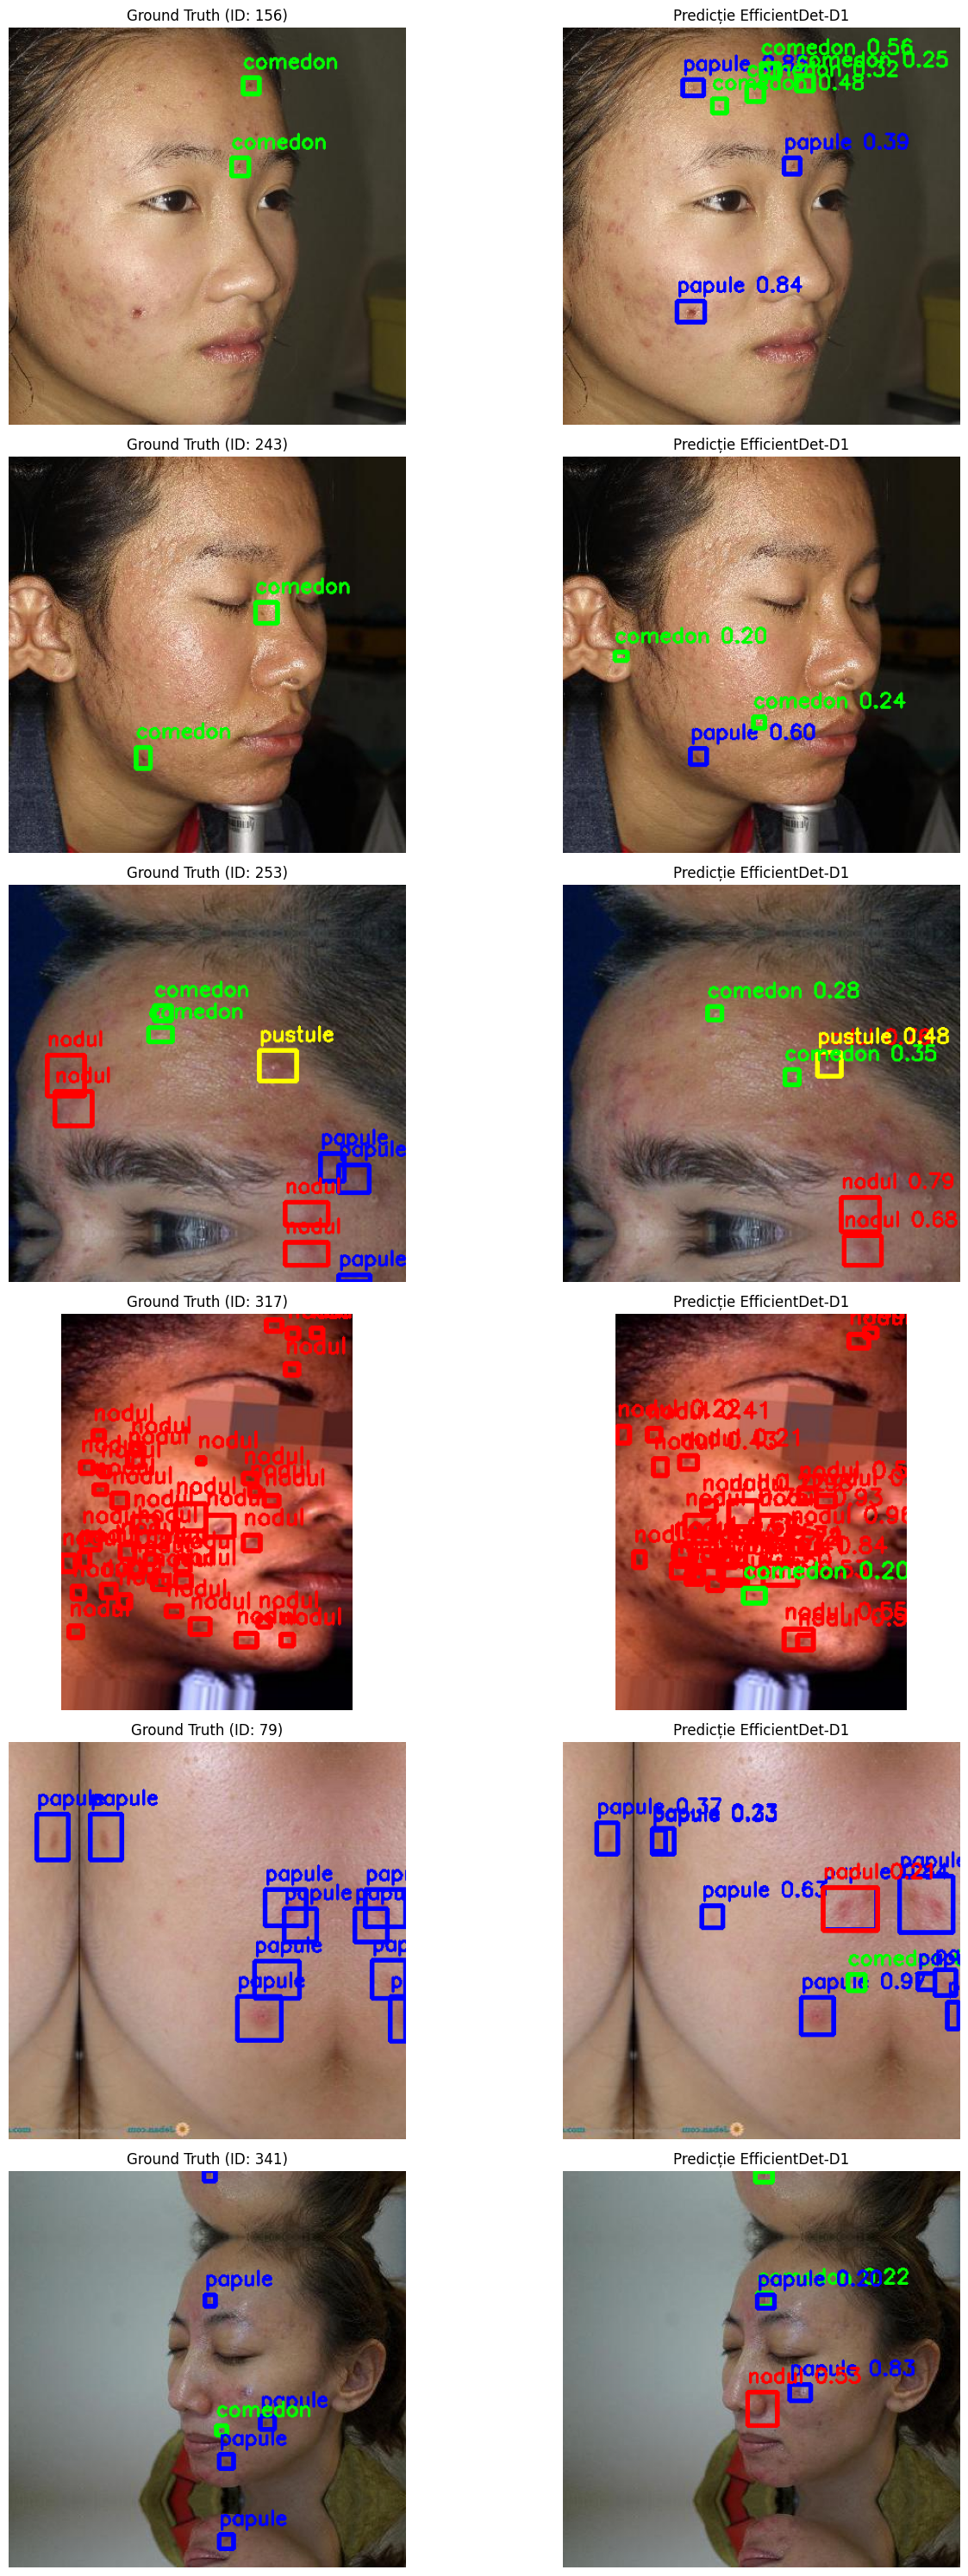

In [ ]:
import torch
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
from effdet import create_model

# 1. CONFIGURARE
MODEL_NAME = 'efficientdet_d1'
NUM_CLASSES = 4
CHECKPOINT_PATH = '/content/drive/MyDrive/YOLO without P5 head/efficientdet_epoch_50.pth'
TEST_JSON = '/content/dataset/test_coco.json'
TEST_IMG_DIR = '/content/dataset/test/images'

# Culori (BGR) și Nume Clase
COLORS = [(0, 255, 0), (255, 0, 0), (0, 0, 255), (255, 255, 0)]
CLASS_NAMES = ['comedon', 'nodul', 'papule', 'pustule']

print("1. Încărcare model și adnotări...")
coco = COCO(TEST_JSON)
model = create_model(MODEL_NAME, bench_task='predict', num_classes=NUM_CLASSES, image_size=(640, 640))
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model = model.cuda().eval()

transform_test = A.Compose([
    A.Resize(640, 640),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Alegem 3 imagini pentru o vizualizare clară (6 poze în total pe ecran)
sample_ids = random.sample(coco.getImgIds(), 6)

fig, axes = plt.subplots(len(sample_ids), 2, figsize=(15, 5 * len(sample_ids)))

for i, img_id in enumerate(sample_ids):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(TEST_IMG_DIR, img_info['file_name'])

    # Imaginea originală pentru Ground Truth
    img_gt = cv2.imread(img_path)
    img_gt = cv2.cvtColor(img_gt, cv2.COLOR_BGR2RGB)

    # Imaginea pentru Predicție
    img_pred = img_gt.copy()
    h_orig, w_orig = img_gt.shape[:2]

    # --- DESENARE GROUND TRUTH ---
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)
    for ann in anns:
        x, y, w, h = ann['bbox']
        cat_id = ann['category_id'] # Aici nu adunăm 1, e ID-ul original din JSON
        cv2.rectangle(img_gt, (int(x), int(y)), (int(x+w), int(y+h)), COLORS[cat_id % 4], 3)
        cv2.putText(img_gt, CLASS_NAMES[cat_id % 4], (int(x), int(y)-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, COLORS[cat_id % 4], 2)

    # --- DESENARE PREDICȚIE ---
    transformed = transform_test(image=img_pred)
    img_tensor = transformed['image'].unsqueeze(0).cuda()

    with torch.no_grad():
        output = model(img_tensor)

    detections = output[0].cpu().numpy()
    scale_x, scale_y = w_orig / 640.0, h_orig / 640.0

    for det in detections:
        score = float(det[4])
        if score > 0.20: # Prag de încredere 20%
            x_min, y_min, x_max, y_max = det[0]*scale_x, det[1]*scale_y, det[2]*scale_x, det[3]*scale_y
            class_id = int(det[5]) - 1 # Scădem 1 pentru ID-ul de afișare

            cv2.rectangle(img_pred, (int(x_min), int(y_min)), (int(x_max), int(y_max)), COLORS[class_id % 4], 3)
            label = f"{CLASS_NAMES[class_id % 4]} {score:.2f}"
            cv2.putText(img_pred, label, (int(x_min), int(y_min)-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, COLORS[class_id % 4], 2)

    # Afișare în coloane
    axes[i, 0].imshow(img_gt)
    axes[i, 0].set_title(f"Ground Truth (ID: {img_id})")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(img_pred)
    axes[i, 1].set_title(f"Predicție EfficientDet-D1")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import json
import cv2
from pathlib import Path

# --- CONFIGURARE ---
# Pune calea către folderul tău principal care conține train, val, test
DATASET_PATH = "/content/Dataset_Curat_YOLO"

# Pune clasele tale exact în ordinea din classes.txt-ul de la YOLO
CLASSES = ["comedo", "nodul", "papule", "pustule"]

def yolo_to_coco(split_name):
    img_dir = Path(DATASET_PATH) / split_name / "images"
    lbl_dir = Path(DATASET_PATH) / split_name / "labels"

    if not img_dir.exists() or not lbl_dir.exists():
        print(f"Skipping {split_name} - folderele nu există.")
        return

    coco_dict = {
        "images": [],
        "annotations": [],
        "categories": [{"id": i, "name": name} for i, name in enumerate(CLASSES)]
    }

    ann_id = 0
    img_id = 0

    # Parcurgem imaginile
    for img_name in os.listdir(img_dir):
        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        img_path = img_dir / img_name
        lbl_path = lbl_dir / (img_path.stem + ".txt")

        # Citim imaginea pentru a afla lățimea și înălțimea reală (esențial pentru COCO)
        img = cv2.imread(str(img_path))
        if img is None: continue
        h_img, w_img = img.shape[:2]

        coco_dict["images"].append({
            "id": img_id,
            "file_name": img_name,
            "width": w_img,
            "height": h_img
        })

        # Dacă are fișier de label, îl procesăm
        if lbl_path.exists():
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) < 5: continue

                    class_id = int(parts[0])
                    cx_norm, cy_norm, w_norm, h_norm = map(float, parts[1:5])

                    # Conversie YOLO (normalizat, centru) -> COCO (absolut, top-left)
                    box_w = w_norm * w_img
                    box_h = h_norm * h_img
                    x_min = (cx_norm * w_img) - (box_w / 2)
                    y_min = (cy_norm * h_img) - (box_h / 2)

                    coco_dict["annotations"].append({
                        "id": ann_id,
                        "image_id": img_id,
                        "category_id": class_id,
                        "bbox": [x_min, y_min, box_w, box_h], # Format COCO
                        "area": box_w * box_h,
                        "iscrowd": 0
                    })
                    ann_id += 1

        img_id += 1

    # Salvăm fișierul JSON
    output_file = Path(DATASET_PATH) / f"{split_name}_coco.json"
    with open(output_file, 'w') as f:
        json.dump(coco_dict, f)
    print(f"Generat cu succes: {output_file} (Imagini: {img_id}, Bounding Boxes: {ann_id})")

# Rulăm pentru toate cele 3 split-uri
for split in ["train", "val", "test"]:
    yolo_to_coco(split)

In [ ]:
from ultralytics import YOLO

model_multi = YOLO('yolov8m.pt')   # pretrained on COCO

results_multi = model_multi.train(
    # ── data ──────────────────────────────────────────────────────────────────
    data='/content/data.yaml',
    imgsz=640,
    batch=16,

    # ── training schedule ─────────────────────────────────────────────────────
    epochs=150,
    patience=25,            # slightly more patience — medical data is noisy
    cos_lr=True,            # cosine LR decay — smoother than step decay
    warmup_epochs=5,        # warm up for 5 epochs before full LR

    # ── optimizer ─────────────────────────────────────────────────────────────
    optimizer='AdamW',      # better than SGD for small/imbalanced datasets
    lr0=5e-4,               # initial LR — lower than default 1e-2 for medical
    lrf=0.01,               # final LR = lr0 * lrf = 5e-6
    weight_decay=5e-4,
    momentum=0.937,

    # ── augmentation — tuned for small dense lesions ──────────────────────────
    mosaic=0.8,             # default 1.0 can destroy micro-lesions context
    mixup=0.1,              # light mixup helps generalisation
    copy_paste=0.3,         # copies small objects — directly helps your 10-20px lesions
    degrees=10.0,           # small rotation
    translate=0.1,
    scale=0.3,              # scale jitter
    fliplr=0.5,
    flipud=0.1,             # faces can be upside down in dataset

    # ── hardware & logging ────────────────────────────────────────────────────
    device=0,
    workers=4,              # Colab has 2 CPUs, keep at 2-4
    save=True,
    plots=True,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_multiclass_v2',
    exist_ok=False,
)

print(f"\nBest mAP@0.5:     {results_multi.results_dict['metrics/mAP50(B)']:.4f}")
print(f"Best mAP@0.5:0.95: {results_multi.results_dict['metrics/mAP50-95(B)']:.4f}")

# **Antrenament SINGLECLASS (Localizator) 640px**

In [ ]:
from ultralytics import YOLO

model_single = YOLO('yolov8m.pt')

results_single = model_single.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=640,
    batch=16,
    device=0,
    single_cls=True,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_singleclass_localizator',

    patience=20,

    save=True,
    plots=True
)

Inițializare model standard YOLOv8m pentru Singleclass...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_singleclass_localizator2, nbs=64, nms=False, opse

# **Antrenament SINGLECLASS (Localizator) 416px**

In [ ]:
from ultralytics import YOLO

model_single = YOLO('yolov8m.pt')

results_single = model_single.train(
    data='/content/data.yaml',
    epochs=150,
    imgsz=416,
    batch=16,
    device=0,
    single_cls=True,
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    name='yolov8m_singleclass_localizator_416',

    patience=20,

    save=True,
    plots=True
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_singleclass_localizator_416, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

# **Evaluare SINGLECLASS pe TEST set**

In [ ]:
from ultralytics import YOLO

# Calea către greutățile modelului localizator
best_single_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_singleclass_localizator2/weights/best.pt'
model_single_eval = YOLO(best_single_path)

lista_iou = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
for iou_p in lista_iou:
  print(f"{iou_p}\n--- EVALUARE SINGLECLASS LOCALIZATOR (TEST SET) ---" )
  metrics_single = model_single_eval.val(
      data='/content/data.yaml',
      split='test',
      single_cls=True,
      conf=0,
      iou=iou_p
  )

0.01
--- EVALUARE SINGLECLASS LOCALIZATOR (TEST SET) ---
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1212.2±672.2 MB/s, size: 26.3 KB)
val: Scanning /content/dataset/test/labels.cache... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 107.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.7it/s 13.8s
                   all        358       3422      0.477      0.468      0.389      0.131
Speed: 2.3ms preprocess, 22.6ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to /content/drive/MyDrive/YOLO without P5 head/runs/detect/val-13
0
--- EVALUARE SINGLECLASS LOCALIZATOR (TEST SET) ---
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, r

In [ ]:
from ultralytics import YOLO

best_single_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_singleclass_localizator2/weights/best.pt'
model_single_eval = YOLO(best_single_path)

lista_conf = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]

for confidence in lista_conf:
  print(f"{confidence}\n--- EVALUARE SINGLECLASS LOCALIZATOR (TEST SET) ---" )
  metrics_single = model_single_eval.val(
      data='/content/data.yaml',
      split='test',
      single_cls=True,
      conf=confidence,
      iou=0.5
  )

0.01
--- EVALUARE SINGLECLASS LOCALIZATOR (TEST SET) ---
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 629.4±176.1 MB/s, size: 24.9 KB)
val: Scanning /content/dataset/test/labels.cache... 358 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 358/358 65.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.8it/s 13.0s
                   all        358       3422      0.471      0.482      0.426      0.145
Speed: 2.4ms preprocess, 22.6ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/drive/MyDrive/YOLO without P5 head/runs/detect/val-25
0.1
--- EVALUARE SINGLECLASS LOCALIZATOR (TEST SET) ---
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, r

# SAHI PE SETUL DE **TEST**

In [ ]:
!pip install -q sahi yolov8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.5/953.5 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.5/417.5 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the so

In [ ]:
!pip install sahi ultralytics pycocotools

In [ ]:
from sahi import AutoDetectionModel

detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path='/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_singleclass_localizator2/weights/best.pt',
    confidence_threshold=0.0,   # equiv. to conf=0 in your original eval
    device="cuda:0",            # or "cpu"
)

In [ ]:
from sahi.predict import predict

predict(
    model_type="ultralytics",
    model_path='/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_singleclass_localizator2/weights/best.pt',
    model_device="cuda:0",
    model_confidence_threshold=0.0,
    source="/path/to/your/test/images/",   # folder with test images
    slice_height=640,
    slice_width=640,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
    dataset_json_path="/path/to/test_coco_annotations.json",  # needed for mAP eval
    project="runs/sahi_eval",
    name="singleclass_test",
    visual_export_format="png",  # optional, saves annotated images
)

2026-04-10 16:43:12,615 - sahi - WARNING - Switching postprocess type/metric to NMS/IOU since confidence threshold is low (0.0). (predict.py:515)


FileNotFoundError: [Errno 2] No such file or directory: '/path/to/test_coco_annotations.json'

In [ ]:
import os
import torch
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from sahi.utils.file import list_files
from sahi.evaluation.coco_evaluator import COCOEvaluator

print("\n--- EVALUARE SAHI SINGLECLASS LOCALIZATOR (TEST SET) ---")

# ==========================================
# CONFIGURĂRI CĂI
# ==========================================
model_path = '/content/drive/MyDrive/YOLO without P5 head/runs/yolov8m_singleclass_localizator2/weights/best.pt'
image_dir = '/content/dataset/test/images'
dataset_json_path = '/content/dataset/test/_annotations.coco.json'

if not os.path.exists(dataset_json_path):
    print(f"\n[EROARE FATALĂ] Nu am găsit fișierul: {dataset_json_path}")
    print("SAHI are nevoie de adnotările de test în format COCO JSON pentru a calcula mAP-ul.")
else:
    # 1. Încărcăm modelul tău în mediul SAHI
    print("Se încarcă modelul YOLOv8 în memoria SAHI...")
    detection_model = AutoDetectionModel.from_pretrained(
        model_type='yolov8',
        model_path=model_path,
        confidence_threshold=0.001, # Prag minim pentru Recall maxim
        device="cuda:0" if torch.cuda.is_available() else "cpu"
    )

    # 2. Inițializăm Evaluatorul COCO
    print("Se pregătește evaluatorul...")
    evaluator = COCOEvaluator(
        ground_truth_image_dir=image_dir,
        ground_truth_annotation_path=dataset_json_path,
    )

    # 3. Generăm predicțiile cu Slicing ("Lupa")
    image_paths = list_files(image_dir)
    print(f"Începem felierea (Slicing) pe {len(image_paths)} imagini. Va dura câteva minute...\n")

    for idx, image_path in enumerate(image_paths):
        # SAHI taie imaginea, rulează YOLO pe fiecare bucată și lipește la loc
        result = get_sliced_prediction(
            image_path,
            detection_model,
            slice_height=640,
            slice_width=640,
            overlap_height_ratio=0.2,
            overlap_width_ratio=0.2,
            postprocess_type="NMS",
            postprocess_match_metric="IOU",
            postprocess_match_threshold=0.01 # Pragul tău NMS
        )

        # Trimitem rezultatele "lipite" către evaluator
        evaluator.update(result.to_coco_predictions(image_id=idx+1))

        if (idx + 1) % 50 == 0 or (idx + 1) == len(image_paths):
            print(f"Procesate {idx + 1}/{len(image_paths)} imagini...")

    # 4. Afișăm rezultatul final
    print("\n--- REZULTATE FINALE SAHI ---")
    evaluator_results = evaluator.evaluate()
    print(evaluator_results)

ModuleNotFoundError: No module named 'sahi.evaluation'

Arhitectura P5 removed, P4 P3 P2 fused si decicion head p2 p3


In [ ]:
# ==========================================
# CELULA 0: INSTALĂRI ȘI MEDIU
# ==========================================

# 1. Instalăm Ultralytics (motorul YOLOv8)
!pip install -q ultralytics

# 2. Ne asigurăm că avem versiunile corecte pentru manipularea JSON/YAML și imagini
!pip install -q pyyaml Pillow opencv-python

# 3. Importăm și verificăm sistemul pentru a fi siguri că avem GPU alocat
import ultralytics
import torch

ultralytics.checks()
print(f"GPU Disponibil: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Nume GPU: {torch.cuda.get_device_name(0)}")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)
GPU Disponibil: True
Nume GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

# Calea corectă către fișierele tale din Google Drive
BASE = '/content/drive/MyDrive/YOLO without P5 head'

# Verificăm dacă dataset-ul a fost deja copiat
if not os.path.exists('/content/dataset'):
    print("Copiem dataset-ul... (ar putea dura 1-2 minute)")
    shutil.copytree(f'{BASE}/Dataset_Curat_YOLO', '/content/dataset')
else:
    print("✅ Dataset-ul este deja la locul lui pe SSD-ul local! Sărim peste copiere.")

# Copy config files (pe acestea le suprascriem mereu ca să fim siguri că avem ultima versiune)
print("Copiem fișierele de configurare...")
for f in ['imcmd_core.py', 'imcmd_yolov8s.yaml', 'data.yaml']:
    shutil.copy(f'{BASE}/{f}', f'/content/{f}')

print("Verificare fișiere mutate:")
# Verify
for split in ['train', 'val', 'test']:
    n = len(os.listdir(f'/content/dataset/{split}/images'))
    print(f'{split}: {n} imagini')

Mounted at /content/drive
Copiem dataset-ul... (ar putea dura 1-2 minute)
Copiem fișierele de configurare...
Verificare fișiere mutate:
train: 1672 imagini
val: 358 imagini
test: 358 imagini


In [ ]:
import sys, torch
sys.path.insert(0, '/content')

# ── Register custom modules ───────────────────────────────────────
from imcmd_core import register_imcmd
register_imcmd()

from ultralytics import YOLO

model = YOLO('/content/imcmd_yolov8s.yaml')

results = model.train(
    data='/content/data.yaml',
    epochs=150,
    batch=4,
    imgsz=640,
    device=0,
    name='imcmd_arhitecturev2',
    project='/content/drive/MyDrive/YOLO without P5 head/runs',
    exist_ok=True,          # don't crash if folder already exists from prev run

    # ── Optimizer (from paper Table 4) ───────────────────────────
    optimizer='SGD',
    lr0=0.01,
    lrf=0.1,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3.0,

    # ── Augmentations (hybrid: paper + dermoscopy-aware) ─────────
    # Color — dermoscopy lighting and skin tone variation
    hsv_h=0.015,      # subtle hue shift
    hsv_s=0.7,        # saturation variation (camera differences)
    hsv_v=0.4,        # brightness variation (flash vs dark)

    # Geometric — rotational invariance critical for skin lesions
    degrees=90.0,     # lesions look identical at any rotation
    flipud=0.5,
    fliplr=0.5,
    translate=0.1,
    scale=0.3,        # compromise: 0.5 paper default, 0.1 killed SAHI

    # Mosaic kept at 0.5 — turning it off (0.0) broke SAHI in your experiments
    mosaic=0.5,

    # Disabled — medically meaningless artifacts
    mixup=0.0,
    erasing=0.0,      # black squares over lesions confuse the model

    # ── Loss weights (from paper) ─────────────────────────────────
    box=7.5,
    cls=0.5,
    dfl=1.5,

    # ── Training settings ─────────────────────────────────────────
    single_cls=True,
    amp=False,         # keep False — more stable on T4 for custom architecture
    patience=20,
    cache=False,
    workers=2,
    save=True,
    save_period=10,    # checkpoint every 10 epochs — survives disconnection
    val=True,
)

✅ 5 module IMCMD înregistrate în Ultralytics:
   • CoordAtt
   • C2f_CA
   • SKA
   • AMFF
   • DynamicHead
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=90.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.0, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/imcmd_yolov8s.yaml, momentum=0.937, mosaic=0.5, multi_scale=0